# H-002 · 1D vs 1H after costs

**Universe C only. No 4H.** Do not fetch, cache, or simulate 4-hour bars.

Compare locked pairs under the H-001 trad-z OLS book: same per-fill `COSTS`, close-`t` signal → fill open `t+1`.
z / HL lookbacks stay session-scaled (`60/252` days × 6 hourly bars). **OLS hedge is 1 quarter of sessions** (`OLS_HEDGE_SESSIONS = 63` in config; change that constant to change both 1D and 1H OLS windows).

Sample: longest overlapping Yahoo 1H window (~730d). Walk-forward on the first 70% of that overlap; one sealed look on the last 30%.

After you type `BAR_STAR`:
- `"1d"` → later hyps use full C 1D with `RESEARCH_IS_END=2021-12-31`
- `"1h"` → later hyps stay on this window with 70/30 IS:OOS


## 0. Imports & Config


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    fold_table,
    fold_val_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    BARS_PER_SESSION_1H,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    load_s1_weekly,
    frozen_pairs_for_universe,
    load_universe_panels,
    lookbacks_for_bar,
    overlay_kalman_hedge,
    overlay_ols_hedge,
    repo_root,
    split_is_oos,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds
from strategies.s2_coint.config import S2SimConfig

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)
# Universe from H-001. PAIRS_STAR is only populated when BOOK_STAR = freeze (H-004);
# otherwise fall back to the ranked frozen book written by H-001.
require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
PAIRS_STAR = list(stack.get("PAIRS_STAR") or frozen_pairs_for_universe(UNIVERSE, "1d", root=ROOT))

# OLS hedge window in trading sessions. 63 ≈ 1 quarter. Change this to change
# 1D and 1H OLS together (1h bars = this × BARS_PER_SESSION_1H).
OLS_HEDGE_SESSIONS = 63


def h002_lookbacks(bar: str) -> dict:
    lb = dict(lookbacks_for_bar(bar))
    scale = BARS_PER_SESSION_1H if bar == "1h" else 1
    lb["ols_window"] = OLS_HEDGE_SESSIONS * scale
    return lb


print("STAR_PATH", STAR_PATH)
print("stack keys:", sorted(stack))
print("UNIVERSE", UNIVERSE, "PAIRS", PAIRS_STAR)
print("OLS_HEDGE_SESSIONS", OLS_HEDGE_SESSIONS, "1d bars", h002_lookbacks("1d")["ols_window"], "1h bars", h002_lookbacks("1h")["ols_window"])


STAR_PATH C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json
stack keys: ['ADF_WINDOW_STAR', 'BAR_STAR', 'BOOK_STAR', 'BREAK_STAR', 'ENTRY_Z_STAR', 'HEDGE_STAR', 'KALMAN_DELTA_STAR', 'OLS_WINDOW_STAR', 'PAIRS_STAR', 'RESEARCH_IS_END_STAR', 'UNIVERSE_STAR', 'Z_WINDOW_STAR']
UNIVERSE D PAIRS ['HEI|HEI.A', 'WSO.B|WSO', 'NWS|NWSA']
OLS_HEDGE_SESSIONS 63 1d bars 63 1h bars 378


## 1. Load frozen 1D panel and fetch 1H (no 4H)


In [2]:
from data.ingestion.equity_fetcher import (
    YFINANCE_1H_MAX_CALENDAR_DAYS,
    fetch_ohlcv,
    yfinance_1h_min_start,
)
from data.processing.s2_coint_store import build_pair_panel
from backtest.s2_coint.research import (
    clip_panel_calendar,
    long_ohlcv_to_frames,
    overlap_calendar_bounds,
    overlap_is_end,
    pair_tuples,
    unique_tickers,
)

assert "4h" not in ("1d", "1h")
train_1d, full_1d = load_universe_panels(UNIVERSE, "1d", PAIRS_STAR, root=ROOT)
tickers = unique_tickers(PAIRS_STAR)
print("tickers", tickers)

# Yahoo 1h wall is 730 calendar days (not bars). Exact end-730 is rejected
# (inclusive lookback + yfinance exclusive end). Helper uses end-(730-2).
START_1H = yfinance_1h_min_start()
print(
    "1h fetch start",
    START_1H.date(),
    "wall",
    YFINANCE_1H_MAX_CALENDAR_DAYS,
    "calendar days",
)
frames_1h = {}
for t in tickers:
    long = fetch_ohlcv(t, START_1H, interval="1h", isAsian=True)
    print(t, "1h rows", len(long), "min", long["date"].min() if len(long) else None, "max", long["date"].max() if len(long) else None)
    frames_1h.update(long_ohlcv_to_frames(long))

lb_1h = h002_lookbacks("1h")
lb_1d = h002_lookbacks("1d")
panel_1h = build_pair_panel(
    frames_1h,
    pair_tuples(PAIRS_STAR),
    ols_window=lb_1h["ols_window"],
    z_window=lb_1h["z_window"],
    hl_window=lb_1h["hl_window"],
    include_adf_pvalue=True,
    include_variance_jump=True,
    hedge="ols",
)
start, end = overlap_calendar_bounds(full_1d["date"], panel_1h["date"])
panel_1d_ov = clip_panel_calendar(full_1d, start, end)
panel_1d_ov = overlay_ols_hedge(
    panel_1d_ov,
    ols_window=lb_1d["ols_window"],
    z_window=lb_1d["z_window"],
    hl_window=lb_1d["hl_window"],
)
panel_1h_ov = clip_panel_calendar(panel_1h, start, end)
print("overlap", start, "→", end, "1d", len(panel_1d_ov), "1h", len(panel_1h_ov))

data_dir = os.path.join(ROOT, "01_data", "data_files", "s2_coint")
os.makedirs(data_dir, exist_ok=True)
panel_1h.to_parquet(os.path.join(data_dir, "s2_panel_C_1h_full.parquet"), index=False)


tickers ['HEI', 'HEI.A', 'WSO.B', 'WSO', 'NWS', 'NWSA']
1h fetch start 2024-08-27 wall 730 calendar days
HEI 1h rows 3473 min 2024-08-27 13:30:00 max 2026-08-24 19:30:00
HEI.A 1h rows 3473 min 2024-08-27 13:30:00 max 2026-08-24 19:30:00
WSO.B 1h rows 79 min 2024-09-09 19:30:00 max 2026-08-24 13:30:00
WSO 1h rows 3473 min 2024-08-27 13:30:00 max 2026-08-24 19:30:00
NWS 1h rows 3473 min 2024-08-27 13:30:00 max 2026-08-24 19:30:00
NWSA 1h rows 3473 min 2024-08-27 13:30:00 max 2026-08-24 19:30:00
overlap 2024-08-27 13:30:00 → 2026-08-24 00:00:00 1d 1494 1h 7010


## 2. 70/30 split on the overlap window


In [3]:
is_end_ov = overlap_is_end(panel_1d_ov, frac=0.70)
is_1d, oos_1d = split_is_oos(panel_1d_ov, is_end=is_end_ov)
is_1h, oos_1h = split_is_oos(panel_1h_ov, is_end=is_end_ov)
s1_weekly = load_s1_weekly(ROOT)
print("overlap IS end", is_end_ov, "1d IS", len(is_1d), "1h IS", len(is_1h))


overlap IS end 2026-01-16 00:00:00 1d IS 1044 1h IS 4887


## 3. Walk-forward folds (per bar)

Unique IS timestamps split into 4 blocks; fold `k` validates on block `k+1`. OLS hedge is **`OLS_HEDGE_SESSIONS` sessions** (63 = 1 quarter), not 252. z still needs `60` sessions (`360` hourly bars). If a val block sits inside that warmup, `pct_z_finite` is ~0, `n_entries` is 0, and Sharpe is NaN. Compare half-life in **sessions** (`median_hl_sessions`).


In [4]:
folds_1d = make_s2_folds(
    pd.DatetimeIndex(pd.to_datetime(is_1d["date"])).unique(),
    n_folds=3,
    embargo_bars=embargo_bars_for_config(bar="1d"),
)
folds_1h = make_s2_folds(
    pd.DatetimeIndex(pd.to_datetime(is_1h["date"])).unique(),
    n_folds=3,
    embargo_bars=embargo_bars_for_config(bar="1h"),
)
print("1D folds")
print(fold_table(folds_1d))
print("1H folds")
print(fold_table(folds_1h))
print("lookbacks bars 1d", h002_lookbacks("1d"))
print("lookbacks bars 1h", h002_lookbacks("1h"))
print("OLS hedge sessions", OLS_HEDGE_SESSIONS, "(1 quarter if 63)")


1D folds
   fold_id train_start  train_end  n_train embargo_start embargo_end  \
0        1  2024-08-28 2024-12-23       82    2024-12-24  2024-12-31   
1        2  2024-08-28 2025-05-01      169    2025-05-02  2025-05-08   
2        3  2024-08-28 2025-09-05      256    2025-09-08  2025-09-12   

   val_start    val_end  n_val  
0 2025-01-02 2025-05-08     87  
1 2025-05-09 2025-09-12     87  
2 2025-09-15 2026-01-16     87  
1H folds
   fold_id         train_start           train_end  n_train  \
0        1 2024-08-27 13:30:00 2024-12-23 17:30:00      574   
1        2 2024-08-27 13:30:00 2025-05-01 15:30:00     1178   
2        3 2024-08-27 13:30:00 2025-09-05 14:30:00     1782   

        embargo_start         embargo_end           val_start  \
0 2024-12-23 18:30:00 2024-12-31 16:30:00 2024-12-31 17:30:00   
1 2025-05-01 16:30:00 2025-05-07 17:30:00 2025-05-07 18:30:00   
2 2025-09-05 15:30:00 2025-09-11 16:30:00 2025-09-11 17:30:00   

              val_end  n_val  
0 2025-05-07 17:

## 4. Fold-val metrics (validation only)

`n_entries` is trades opened in that val window. `pct_z_finite` is the share of val rows with a usable z. `median_hl_sessions` is OU half-life in **sessions** (1h bars ÷ 6) so 1D and 1H are comparable.

- n_days is meant to read n_rows


In [5]:
cfg_1d = config_from_stack(stack, bar="1d", ols_window=h002_lookbacks("1d")["ols_window"])
cfg_1h = config_from_stack(stack, bar="1h", ols_window=h002_lookbacks("1h")["ols_window"])
df_1d = fold_val_metrics(is_1d, folds_1d, {"1d": cfg_1d}, s1_weekly=s1_weekly)
df_1h = fold_val_metrics(is_1h, folds_1h, {"1h": cfg_1h}, s1_weekly=s1_weekly)
fold_df = pd.concat([df_1d, df_1h], ignore_index=True)
fold_df


,arm,fold_id,ann_sharpe,max_drawdown,corr_to_s1,n_days,n_entries,pct_z_finite,median_hl_bars,median_hl_sessions
0,1d,1,2.272280,-0.020344,0.209157,85,5,0.609195,NaN,NaN
1,1d,2,-1.379608,-0.008519,-0.242729,85,3,1.000000,6.447458,6.447458
2,1d,3,2.658846,-0.007142,-0.049044,85,5,1.000000,5.988546,5.988546
3,1h,1,0.208150,-0.008010,0.226121,602,5,0.765612,NaN,NaN
4,1h,2,-0.246635,-0.006205,-0.319846,602,4,0.995878,28.042103,4.673684
5,1h,3,0.489954,-0.005423,-0.271297,602,5,0.987735,28.366273,4.727712


## 5. Boxplots (do not assign STAR here)


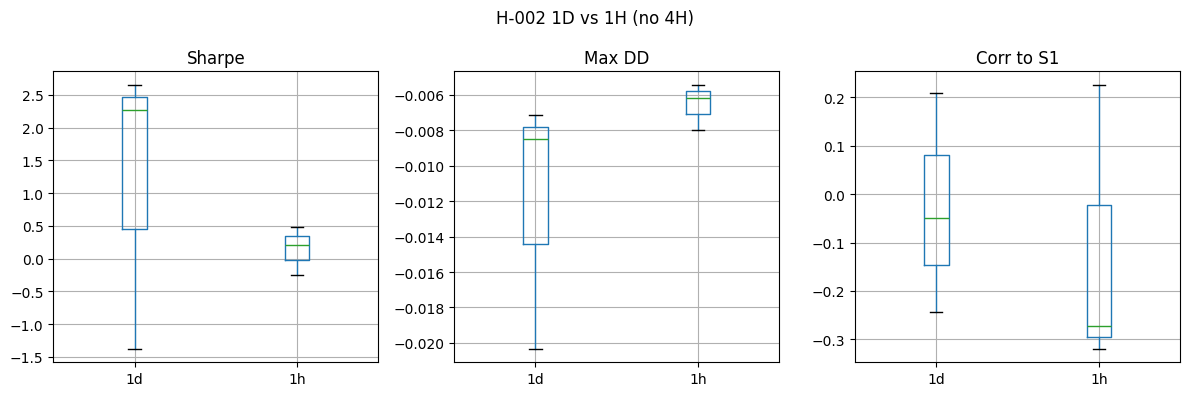

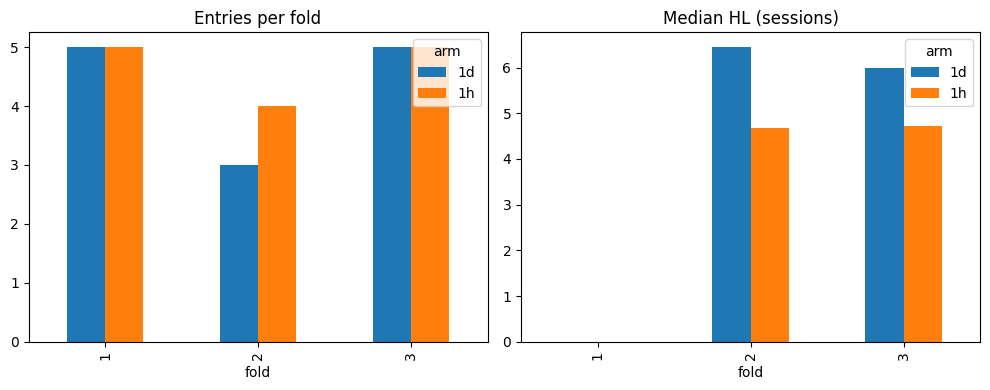

median-Sharpe hint (commentary only): 1d


,ann_sharpe,max_drawdown,corr_to_s1,n_entries,pct_z_finite,median_hl_sessions
arm,,,,,,
1d,2.27228,-0.008519,-0.049044,5.0,1.000000,6.218002
1h,0.20815,-0.006205,-0.271297,5.0,0.987735,4.700698


In [6]:
plot_fold_boxplots(fold_df, title="H-002 1D vs 1H (no 4H)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fold_df.pivot(index="fold_id", columns="arm", values="n_entries").plot(
    kind="bar", ax=axes[0], title="Entries per fold"
)
fold_df.pivot(index="fold_id", columns="arm", values="median_hl_sessions").plot(
    kind="bar", ax=axes[1], title="Median HL (sessions)"
)
axes[0].set_xlabel("fold")
axes[1].set_xlabel("fold")
plt.tight_layout()
plt.show()

print("median-Sharpe hint (commentary only):", median_sharpe_hint(fold_df))
cols = [
    "ann_sharpe",
    "max_drawdown",
    "corr_to_s1",
    "n_entries",
    "pct_z_finite",
    "median_hl_sessions",
]
fold_df.groupby("arm")[cols].median()


## 6. Type `BAR_STAR` then save


In [7]:
BAR_STAR = "1d"  # TODO set after review: "1d" or "1h" — do not use argmax
require_star("BAR_STAR", BAR_STAR)
stack["BAR_STAR"] = BAR_STAR
save_star_stack(STAR_PATH, stack)
print("wrote", STAR_PATH)


wrote C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json


## 7. Sealed OOS once (last 30% of overlap)


In [8]:
require_star("BAR_STAR", BAR_STAR)
oos_panel = oos_1d if BAR_STAR == "1d" else oos_1h
oos_cfg = config_from_stack(
    stack, bar=BAR_STAR, ols_window=h002_lookbacks(BAR_STAR)["ols_window"]
)
oos = run_s2_backtest(oos_panel, oos_cfg, s1_weekly=s1_weekly)
print(oos.metrics)
write_tearsheet_pdf(tearsheet_path("H-002", BAR_STAR), oos.returns, title=f"H-002 {BAR_STAR} sealed OOS")


{'ann_sharpe': 1.4152110262626796, 'max_drawdown': -0.020189986874918908, 'n_days': 148, 'corr_to_s1': -0.09448956109911587}


## 8. Sample-rule fork for later hyps


If `BAR_STAR == "1d"`: later notebooks load `s2_panel_C_1d_{train,full}.parquet` and cut OOS at `2021-12-31`.

If `BAR_STAR == "1h"`: later notebooks load `s2_panel_C_1h_full.parquet` and use a 70/30 split on this overlap window. Optional: `s2_pair_panel_1h.ipynb` only if you need to rebuild the 1H panel.

H-003 cointegration-break flat rule is next, then H-004 book construction, then the H-005 window screens (Kalman is H-006). Never re-open `BAR_STAR`.


In [9]:
if BAR_STAR == "1h":
    is_h, _ = split_is_oos(panel_1h_ov, is_end=is_end_ov)
    is_h.to_parquet(os.path.join(data_dir, "s2_panel_C_1h_train.parquet"), index=False)
    print("wrote 1h train parquet")
else:
    print("1D wins: later hyps use full C 1D research IS through 2021-12-31")


1D wins: later hyps use full C 1D research IS through 2021-12-31
